In [1]:
import pandas as pd
import numpy as np
import os
import glob
import shutil
import scipy.stats as stats
import scipy.signal as signal
from scipy.ndimage import gaussian_filter1d
import sys

In [2]:
import Waveform_Isolation as WI

# Recursively find all CSV files in the Simulated_Waveforms directory
search_path = os.path.join('Simulated_Waveforms', '*.csv')
channel_files = glob.glob(search_path)

results = [] # This list will be passed by reference to accumulate results

if not channel_files:
    print(f"No channel files found in {search_path}")
    sys.exit()

# Read all channels into a dictionary of dataframes, to be used later
# At the same time, process each channel and isolate the waveforms
print(f"Loading {len(channel_files)} channel files into memory...")
channel_dataframes = {}
for filepath in channel_files:
    filename = os.path.basename(filepath)
    try:
        # Load the CSV file without headers
        df = pd.read_csv(filepath, header=None)
        WI.process_file(df, filepath, results, WI.PRE_TRIGGER_SAMPLES, WI.POST_TRIGGER_SAMPLES)
        channel_dataframes[filename] = df
    except Exception as e:
        print(f"  Error loading {filename}: {e}")
        
if not channel_dataframes:
    print("No dataframes loaded. Exiting.")
    sys.exit()

    # After processing all files, save the accumulated results to a single CSV
if results:
    indices_df = pd.DataFrame(results)
    indices_df.to_csv('Waveform_Analysis.csv', index=False)
    print(f"\nSuccessfully saved {len(results)} waveform entries to 'Waveform_Indices.csv'")
else:
    print("\nNo waveforms isolated. Summary file not created.")

Loading 4 channel files into memory...
Processed Ch1.csv -> Saved 22 waveforms
Processed Ch2.csv -> Saved 24 waveforms
Processed Ch3.csv -> Saved 26 waveforms
Processed Ch4.csv -> Saved 23 waveforms

Successfully saved 95 waveform entries to 'Waveform_Indices.csv'


In [3]:
import Envelope_Analysis as EA

EA.cluster_waveforms(channel_dataframes)

Processing Ch1.csv_#1...
Processing Ch1.csv_#2...
  Comparing vs Group 1: D = 0.8221
  -> No match. Created Group 2.
Processing Ch1.csv_#3...
  Comparing vs Group 1: D = 0.6699
  Comparing vs Group 2: D = 0.7485
  -> No match. Created Group 3.
Processing Ch1.csv_#4...
  Comparing vs Group 1: D = 0.5878
  Comparing vs Group 2: D = 0.5740
  Comparing vs Group 3: D = 0.6523
  -> No match. Created Group 4.
Processing Ch1.csv_#5...
  Comparing vs Group 1: D = 1.0839
  Comparing vs Group 2: D = 1.0633
  Comparing vs Group 3: D = 0.9543
  Comparing vs Group 4: D = 1.0428
  -> No match. Created Group 5.
Processing Ch1.csv_#6...
  Comparing vs Group 1: D = 0.9320
  Comparing vs Group 2: D = 0.9469
  Comparing vs Group 3: D = 0.9821
  Comparing vs Group 4: D = 0.8029
  Comparing vs Group 5: D = 1.6080
  -> No match. Created Group 6.
Processing Ch1.csv_#7...
  Comparing vs Group 1: D = 0.8947
  Comparing vs Group 2: D = 0.8128
  Comparing vs Group 3: D = 0.7286
  Comparing vs Group 4: D = 0.8776


{1: [[['Ch1.csv', np.int64(1)],
   ['Ch2.csv', np.int64(1)],
   ['Ch3.csv', np.int64(1)],
   ['Ch4.csv', np.int64(1)]],
  array([0.0084546 , 0.00845204, 0.00844877, ..., 0.00723606, 0.00723692,
         0.00723789], shape=(6292,))],
 2: [[['Ch1.csv', np.int64(2)],
   ['Ch2.csv', np.int64(3)],
   ['Ch3.csv', np.int64(3)],
   ['Ch4.csv', np.int64(3)]],
  array([0.0078682 , 0.00786747, 0.00786623, ..., 0.02102873, 0.02099699,
         0.02097593], shape=(6298,))],
 3: [[['Ch1.csv', np.int64(3)]],
  array([0.01395709, 0.01395327, 0.01394578, ..., 0.01639317, 0.0163983 ,
         0.01640081], shape=(6300,))],
 4: [[['Ch1.csv', np.int64(4)],
   ['Ch2.csv', np.int64(4)],
   ['Ch3.csv', np.int64(4)],
   ['Ch4.csv', np.int64(4)]],
  array([0.00439997, 0.00439888, 0.00439701, ..., 0.00441726, 0.00441947,
         0.00442084], shape=(6299,))],
 5: [[['Ch1.csv', np.int64(5)], ['Ch2.csv', np.int64(5)]],
  array([0.00231429, 0.00231461, 0.00231504, ..., 0.00166492, 0.00166338,
         0.00166184], 

In [4]:
import Wavelet_Decomposition as WD
# 2. Pre-load channel files into memory


# 3. Process each isolated waveform
print(f"Extracting features for {len(indices_df)} waveforms...")

results = []

for i, row in indices_df.iterrows():
    filename = row['input filename']
    start_idx = int(row['start idx'])
    end_idx = int(row['end idx'])
    count = row['count']
    
    # Extract signal from the pre-loaded dataframes
    try:
        df = channel_dataframes[filename]
        signal_segment = df.iloc[start_idx:end_idx, 1].values
        
        # Extract features
        energies = WD.calculate_wavelet_energy(signal_segment)
        
        if energies is not None:
            res_row = {
                'input filename': filename,
                'count': count,
                'Energy_A5': energies[0],
                'Energy_D5': energies[1],
                'Energy_D4': energies[2],
                'Energy_D3': energies[3],
                'Energy_D2': energies[4],
                'Energy_D1': energies[5]
            }
            results.append(res_row)
            
    except Exception as e:
        print(f"Error processing {filename} #{count}: {e}")

# 4. Save results to CSV
if results:
    new_df = pd.DataFrame(results)
        
    if os.path.exists(WD.OUTPUT_FILE):
        existing_df = pd.read_csv(WD.OUTPUT_FILE)
        # Merge new results as columns. 
        # We assume 'Filename' is the common identifier for rows.
        if 'input filename' in existing_df.columns and 'count' in existing_df.columns:
            # Merge on Filename and Count to ensure rows match correctly
            # 'outer' join ensures we don't lose rows
            final_df = pd.merge(existing_df, new_df, on=['input filename', 'count'], how='outer')
        else:
            # Fallback: if keys are missing, just concatenate columns
            final_df = pd.concat([existing_df, new_df], axis=1)
        
        final_df.to_csv(WD.OUTPUT_FILE, index=False)
        print(f"Processing complete. Data appended as columns to {WD.OUTPUT_FILE}")
    else:
        new_df.to_csv(WD.OUTPUT_FILE, index=False)
        print(f"Processing complete. Data saved to {WD.OUTPUT_FILE}")
else:
    print("No features extracted.")

Extracting features for 95 waveforms...
Processing complete. Data appended as columns to Waveform_Analysis.csv


Loading data from Waveform_Analysis.csv...
Computing Principal Components...
Explained Variance by component: [8.63506852e-01 1.36167651e-01 1.93922523e-04]
Total Information Retained: 99.99%
PCA results appended to Waveform_Analysis.csv
Generating 3D Plot...


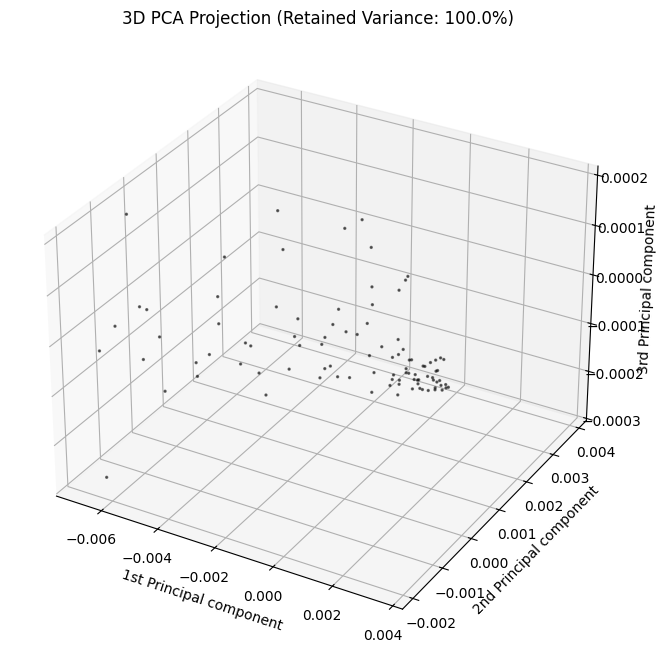

In [5]:
import Principal_Component_Analysis as pca

pca.perform_pca_and_visualize('Waveform_Analysis.csv')

Loading data from Waveform_Analysis.csv...
Running DBSCAN with eps=0.0002 and min_samples=5...
Estimated number of clusters: 2
Estimated number of noise points: 64
Clustered data saved back to Waveform_Analysis.csv
Generating 3D Cluster Plot...


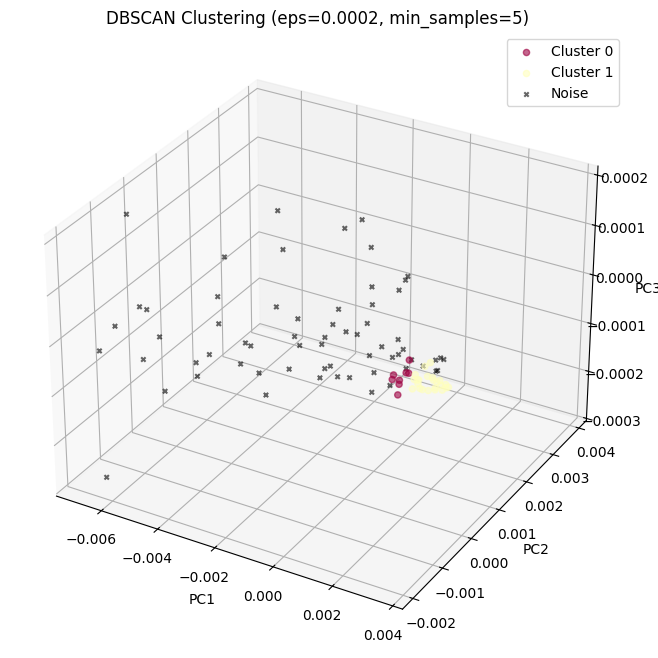

In [6]:
import DBSCAN as dbscan

dbscan.perform_dbscan_clustering('Waveform_Analysis.csv')